# **Complete EDA Course**

### DATA UNDERSTANDING

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #Advanced visualization library.

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

**EXPLANATION :**
**NumPy**
Imported as: np
Used for:
numerical calculations
arrays
mathematical operations

**Pandas**
Imported as: pd
Used for:
dataset handling
tables
filtering
analysis

**Matplotlib**
Used for:
basic plotting
graphs
charts

**Seaborn**
Used for:
beautiful statistical visualizations
advanced EDA plots

**Warnings**
warnings.filterwarnings("ignore")
Hides unnecessary warnings.
Makes notebook cleaner.

### Load Dataset

In [3]:
df = pd.read_csv('D:/DL_ML_AI_DS/AI_2026/EDA_Project/ai4i2020.csv')

### View Data

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### About Dataset:
**This dataset contains:** Vehicle / machine sensor data
The sensors record:
temperature, rotational speed, torque, tool wear, machine status
And finally: whether machine FAILED or NOT.

**REAL-WORLD UNDERSTANDING : **
Imagine: a smart factory. Machines continuously generate sensor values.

**AI system predicts:** "Will machine fail soon?"

This is called: Predictive Maintenance

Let us understand EACH column.

**1. UDI: Unique ID :** Example: 1, 2, 3, 4..... Just serial number.

**2. Product ID:** Example:M14860, L47181
Machine/product identifier.

**3. Type :** Machine quality category.
Possible values:
L = Low
M = Medium
H = High

This is categorical data. We need to convert into numbers.

**4. Air temperature [K] :** Environmental temperature.
Unit: Kelvin (K)
Example: 300 K

**5. Process temperature [K] :** Machine internal operating temperature.
Higher values may indicate:
stress, overheating, failure risk

**6. Rotational speed [rpm] :** RPM means: Revolutions Per Minute
How fast machine rotates.
Example: 1500 rpm

**7. Torque [Nm] :** Torque means: rotational force
Unit: Newton-meter
High torque may indicate:
machine stress, overload

**8. Tool wear [min] :** How long tool has been used.
Higher wear:
→ higher failure probability.

**9. Machine failure :** THIS IS THE TARGET VARIABLE.
Values:
0 = No failure
1 = Failure

**PROJECT GOAL :** Our AI model learns:
Given sensor data, predict whether machine will fail or not.

### Datset shape (rows, columns)

In [5]:
df.shape

(10000, 14)

### Column Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

## Statistical Summary

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Missing values

In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

## Target Distribution

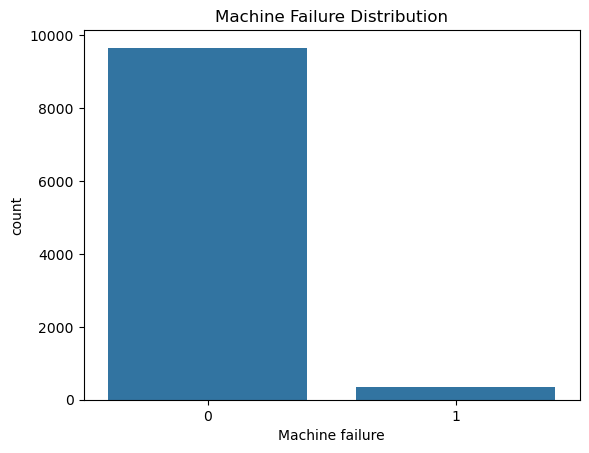

In [11]:
sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()

## Correlation Heatmap

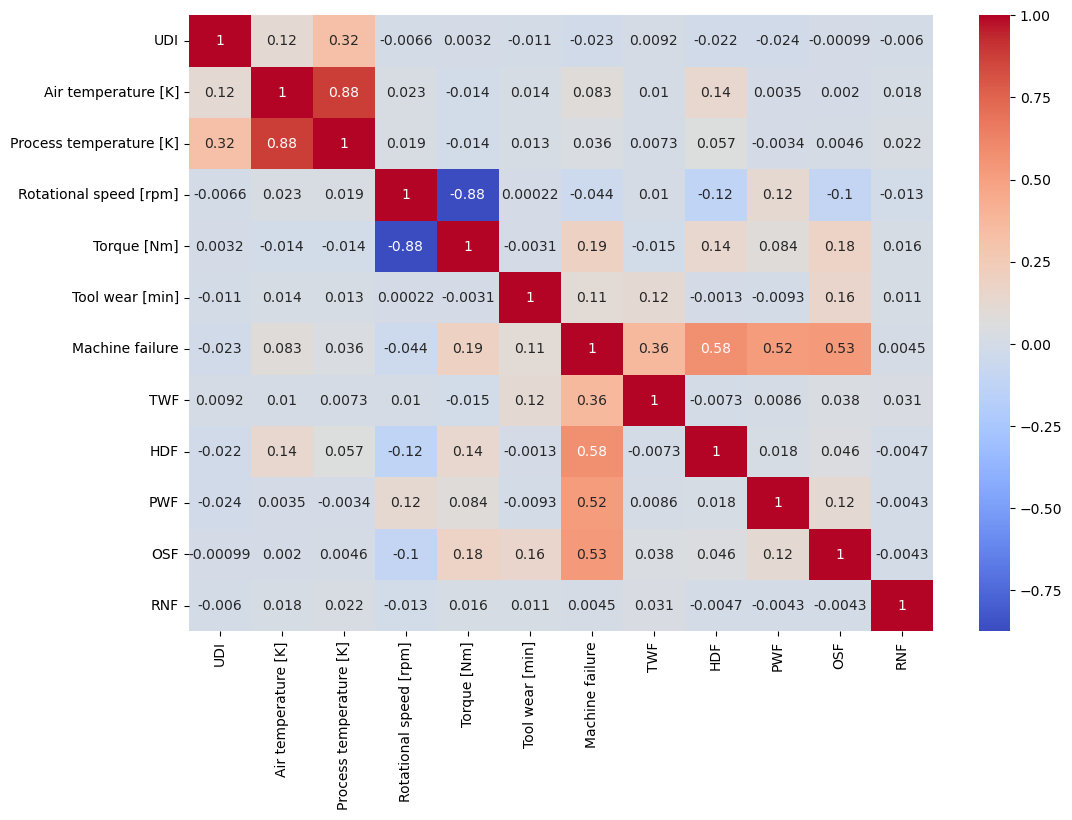

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
            )
plt.show()

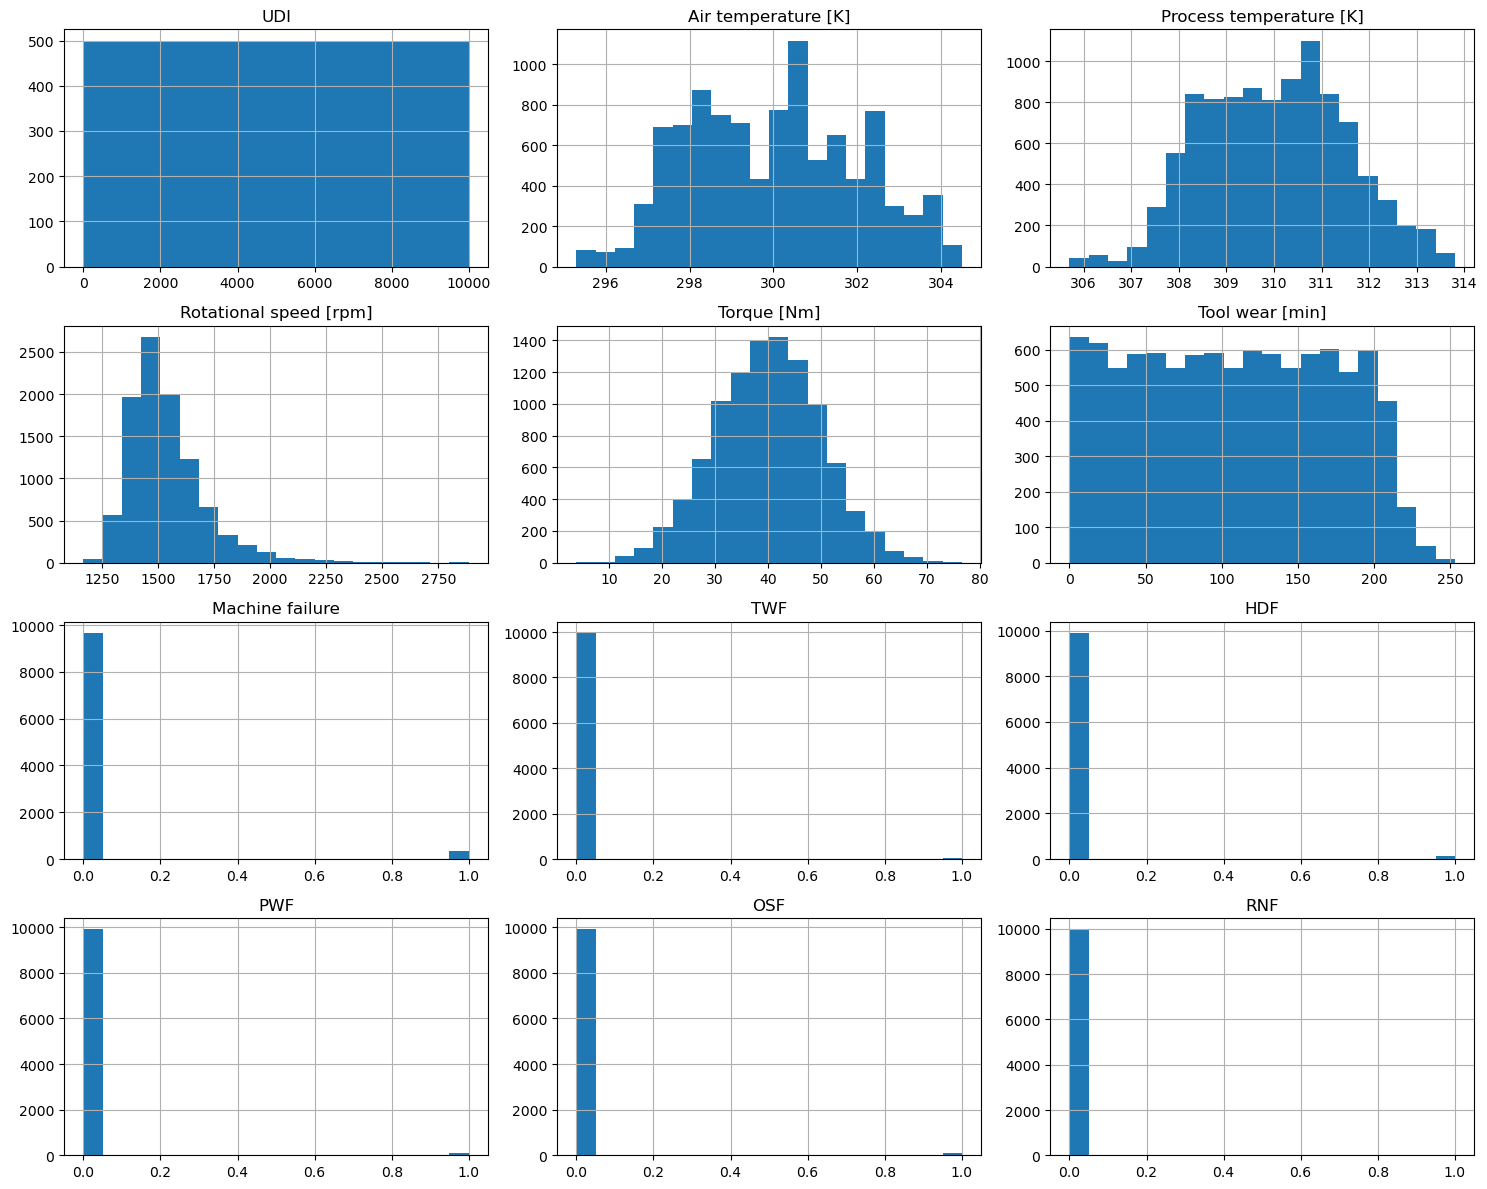

In [13]:
df.hist(
    figsize=(15,12), #15 width, 12 height
    bins=20
)

plt.tight_layout()

plt.show()

## Univariant Analysis
Uni = One

Variate = Variable

Univariate Analysis = analyzing one variable/one column at a time


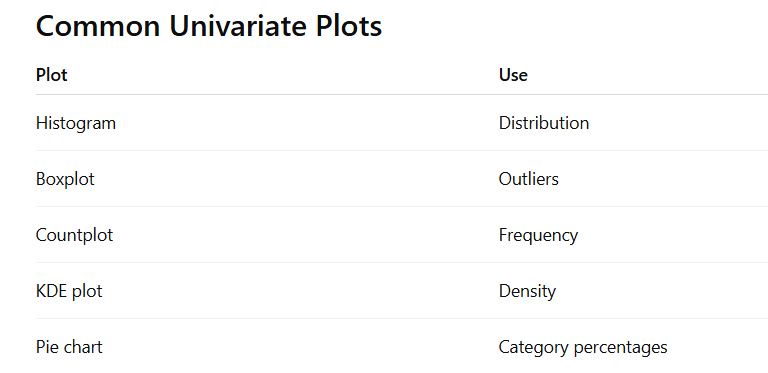

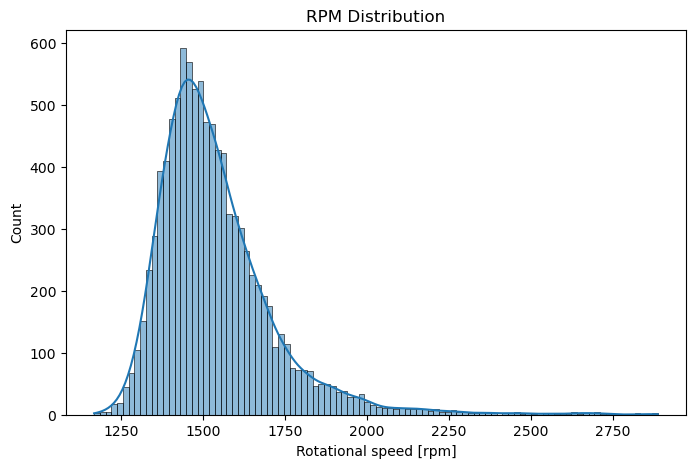

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Rotational speed [rpm]"],
    kde=True #kde means adds smooth curve
)
plt.title("RPM Distribution")
plt.show()

## Bivariant Analysis

Analyzing relationship between:
TWO variables are involved

Here: torque, machine failure

A boxplot shows: minimum value, maximum value, median, spread of data, outliers

Very useful in EDA.

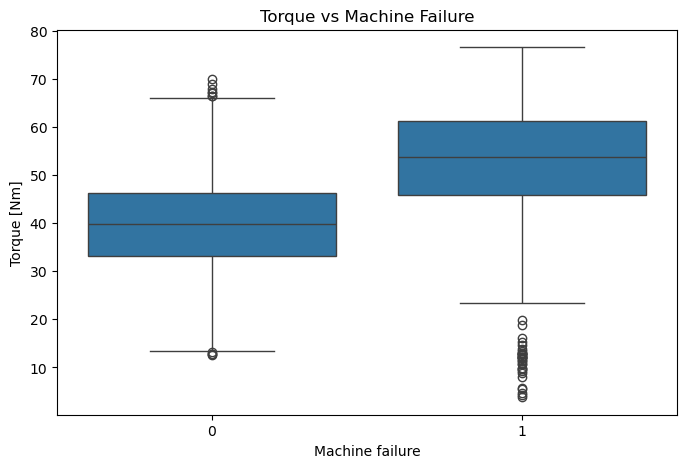

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Machine failure"],
    y=df["Torque [Nm]"]
)

plt.title("Torque vs Machine Failure")
plt.show()

##  Multivariate Analysis
multiple features together

Helps identify:
feature interactions, class separation, hidden patterns

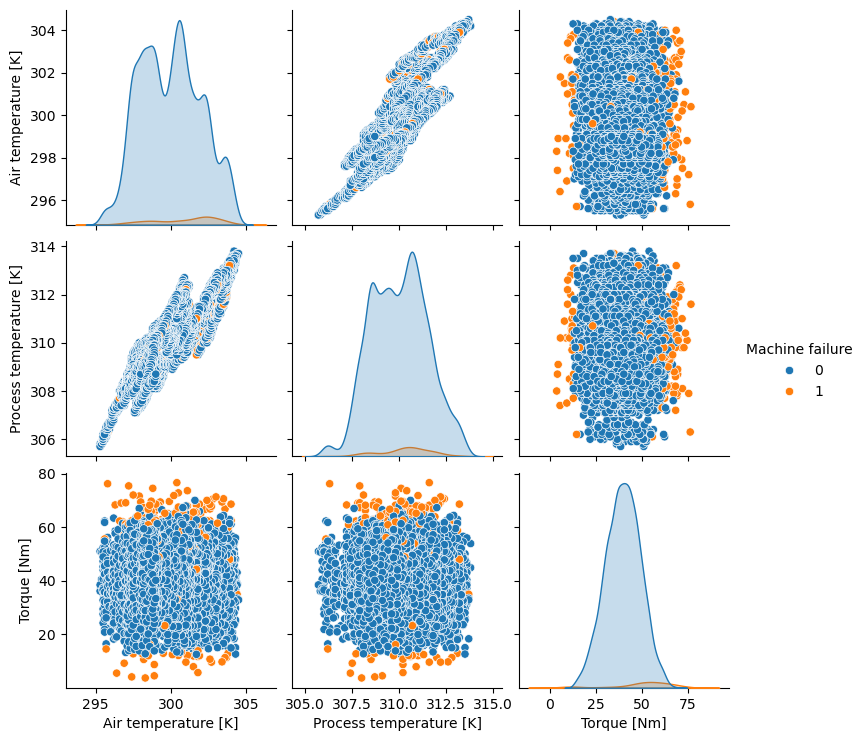

In [16]:
sns.pairplot(
    df[
        [
            "Air temperature [K]",
            "Process temperature [K]",
            "Torque [Nm]",
            "Machine failure"
        ]
    ],
    hue="Machine failure"
)

** Analysis:

Insights

1. Higher torque appears associated with machine failure.

2. Temperature differences may indicate machine stress.

3. Tool wear likely contributes to operational degradation.

4. Dataset appears slightly imbalanced.

5. Sensor analytics can help predictive maintenance systems reduce downtime.

# **DATA CLEANING & PREPROCESSING**

**LabelEncoder**

Used for: converting text into numbers

ML models cannot understand:

L
M
H

So we encode them.

**StandardScaler**

Used for: feature scaling

Important because:
sensor values have different ranges.

Example:

**Feature	 Range**

RPM    	1000–3000

Torque	10–100

Without scaling:

large-value features dominate learning.

In [17]:
df.head() #view 1st rows

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [18]:
df.isnull().sum() #CHECK MISSING VALUES

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [19]:
# HANDLE NULL VALUES
# Even if dataset has no nulls, we still write proper production code.
df = df.fillna(df.median(numeric_only=True)) #finding numeric missing values using: median
#WHY MEDIAN? Median is robust against: outliers, abnormal values

In [20]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [21]:
# CHECK DUPLICATES
df.duplicated().sum()

np.int64(0)

In [22]:
# REMOVE DUPLICATES
# If we have duplicates we can use this to drop
df = df.drop_duplicates()

In [23]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [24]:
#VERIFY REMOVAL
df.duplicated().sum()

np.int64(0)

In [25]:
# CHECK DATA TYPES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### object: categorical text data, We must encode it.

In [26]:
# LABEL ENCODING
encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])

#converts L:0, M=1, H=2

In [27]:
# VERIFY ENCODING
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  int64  
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(10

In [29]:
# REMOVE UNNECESSARY COLUMNS
# Examples UDI, Product Type: these are identifiers only. They DO NOT help prediction.
# WHY REMOVE THEM? Identifiers will add noise, reduce generalization, may cause overfitting
df = df.drop(columns=["UDI", "Product ID"])

In [30]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [31]:
df.shape

(10000, 12)

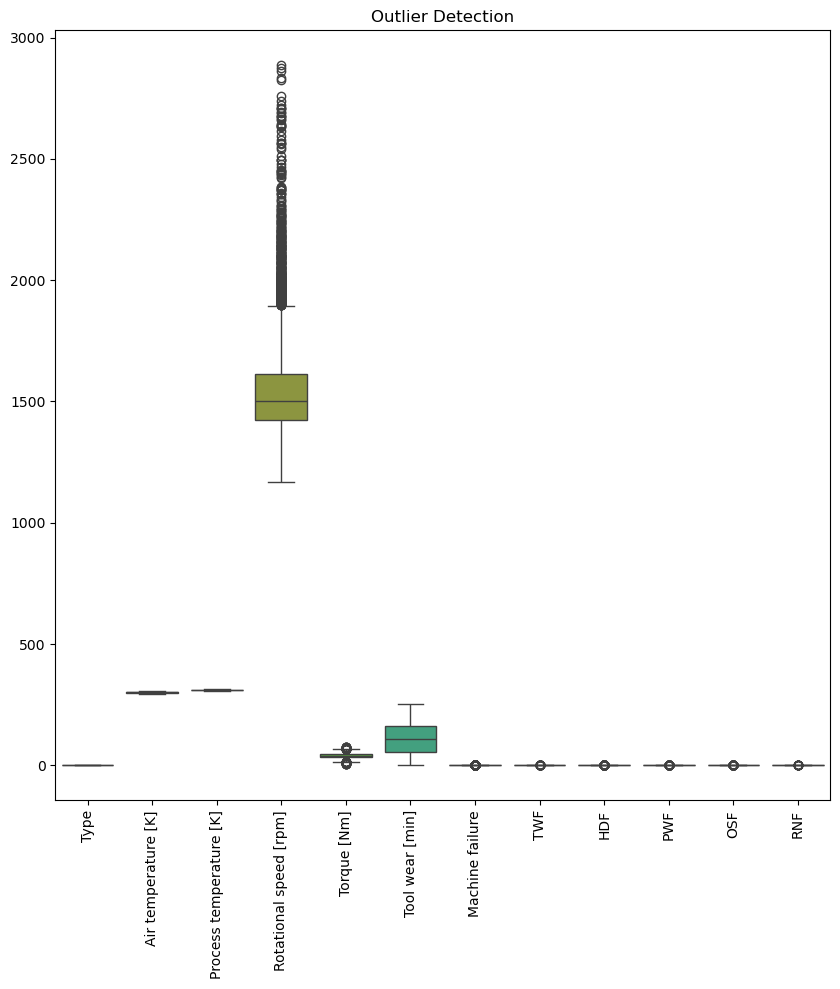

In [32]:
# OUTLIER DETECTION
plt.figure(figsize=(10, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

**Boxplots help identify:**

abnormal sensor readings, extreme values, anomalies
and also it will do predictive maintenance, sensor analytics

WHAT IS AN OUTLIER?

Outlier: abnormal/extreme value

Example:

Normal RPM  : 1500
Outlier RPM : 15000

Outliers may: distort ML learning, reduce accuracy

WHY WE ARE NOT REMOVING OUTLIERS

For predictive maintenance:

Extreme values often indicate:

impending failures
abnormal sensor behavior
machine degradation

These are valuable signals.

Removing them can reduce model performance.

In [33]:
# # OUTLIER TREATMENT USING IQR(Interquartile Range )
# numeric_columns = df.select_dtypes(include=[np.number]).columns

In [34]:
# numeric_columns #only numerical columns.

**IQR = Interquartile Range**

Formula: IQR=Q3−Q1

Used for: detecting extreme values

WHY IQR METHOD?

Good for: skewed data, sensor analytics, anomaly-heavy systems

In [35]:
# for column in numeric_columns:
#   Q1 = df[column].quantile(0.25)
#   Q3 = df[column].quantile(0.75)

#   IQR = Q1- Q3

#   lower_limit = Q1 - 1.5 * IQR
#   higher_limit = Q3 + 1.5 * IQR

#   df = df[
#       (df[column] >= lower_limit) &
#       (df[column] <= higher_limit)
#   ]

# CHECK SHAPE AFTER OUTLIER REMOVAL
# df.shape

In [36]:
df.shape

(10000, 12)

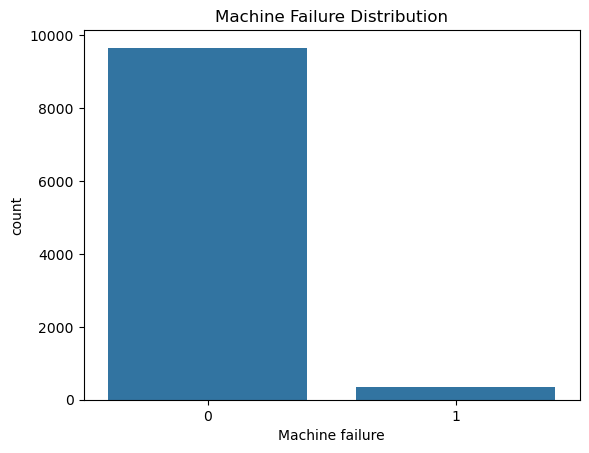

In [37]:
# CHECK CLASS DISTRIBUTION
sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()

In [38]:
# CHECK NUMERICAL SUMMARY
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,10000.0,1.19940,0.600230,0.0,1.0,1.0,2.0,2.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0


In [39]:
df.to_csv("Cleaned_EDA_Data.csv", index=False)

In [40]:
# Final Version of Data
print("Final Shape:", df.shape)

Final Shape: (10000, 12)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF                      10000 non-null  int64  
 10  OSF                      10000 non-null  int64  
 11  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 937.6 KB


# Data Cleaning Insights

1. No major missing values were found.

2. Duplicate records were removed to avoid training bias.

3. Machine type was encoded for machine learning compatibility.

4. Identifier columns were removed because they do not contribute to predictive learning.

5. Outliers were retained because extreme sensor readings are important indicators of machine failure.

6. Dataset is now clean and ready for advanced exploratory data analysis.

## **Advanced EDA Implementation**

In [42]:
# Load clean Dataset
df = pd.read_csv("/content/Cleaned_EDA_Data.csv")

print(df.shape) #Dataset Overview

FileNotFoundError: [Errno 2] No such file or directory: '/content/Cleaned_EDA_Data.csv'

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Univariate Analysis: Analyze one feature at a time.

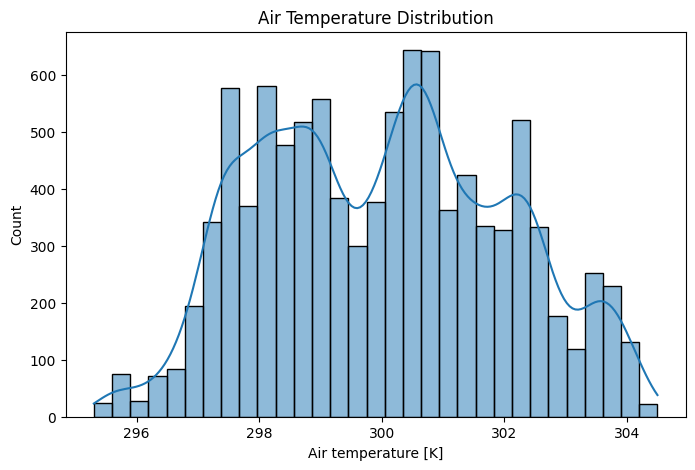

In [ ]:
# Air Temperature
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Air temperature [K]"],
    kde=True
    #kde stands for Kernel Density Estimation.
    #It adds a smooth, continuous curve over the histogram bars to represent the probability distribution of the data.
)
plt.title("Air Temperature Distribution")

plt.show()

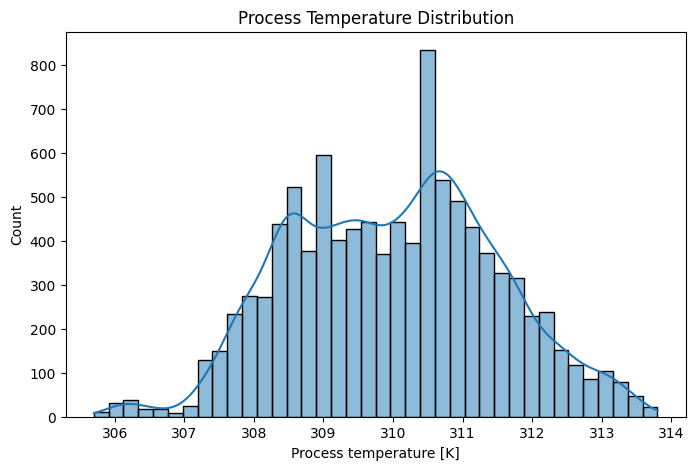

In [ ]:
# Process Temperature
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Process temperature [K]"],
    kde=True
)
plt.title("Process Temperature Distribution")

plt.show()

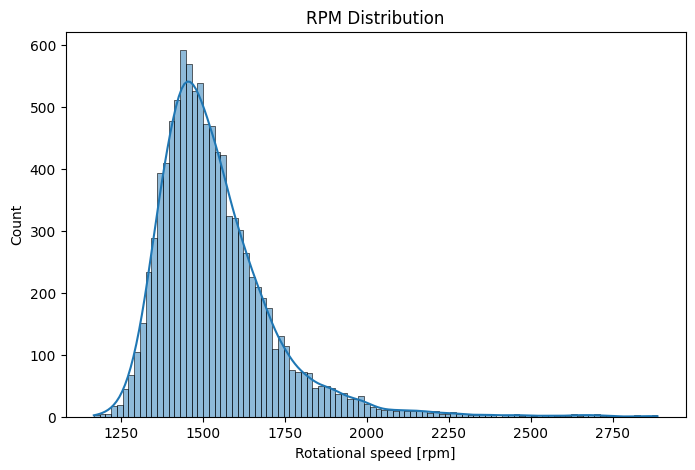

In [ ]:
# RPM Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Rotational speed [rpm]"],
    kde=True
)

plt.title("RPM Distribution")

plt.show()

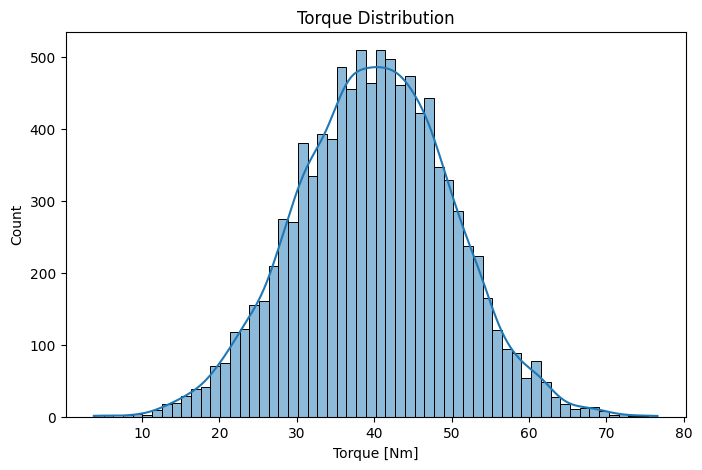

In [ ]:
# Torque Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Torque [Nm]"],
    kde=True
)

plt.title("Torque Distribution")

plt.show()

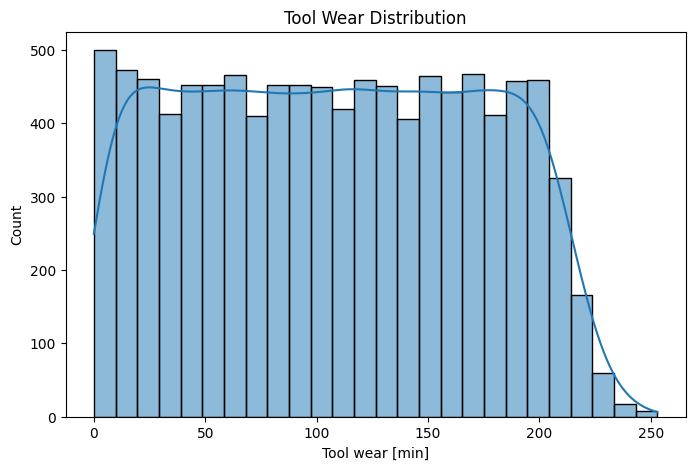

In [ ]:
# Tool Wear Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Tool wear [min]"],
    kde=True
)

plt.title("Tool Wear Distribution")

plt.show()

In [ ]:
# Failure Analysis
failure_counts = df["Machine failure"].value_counts()

In [ ]:
failure_counts

,count
Machine failure,
0,9661
1,339


In [ ]:
failure_Percentage = df["Machine failure"].value_counts(normalize=True)*100

In [ ]:
failure_Percentage

,proportion
Machine failure,
0,96.61
1,3.39


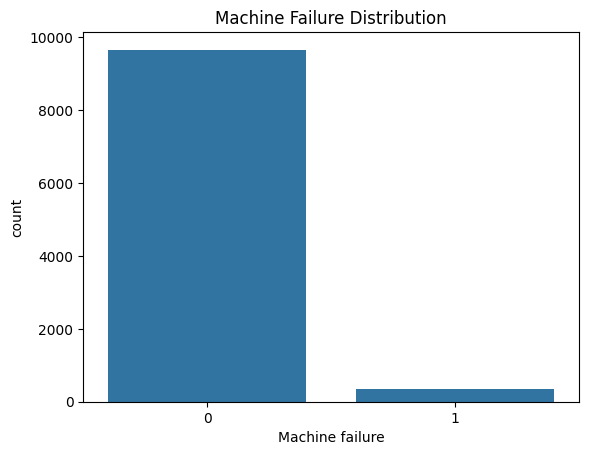

In [ ]:
sns.countplot(
    x=df["Machine failure"]
)

plt.title("Machine Failure Distribution")

plt.show()

### Bivariate Analysis

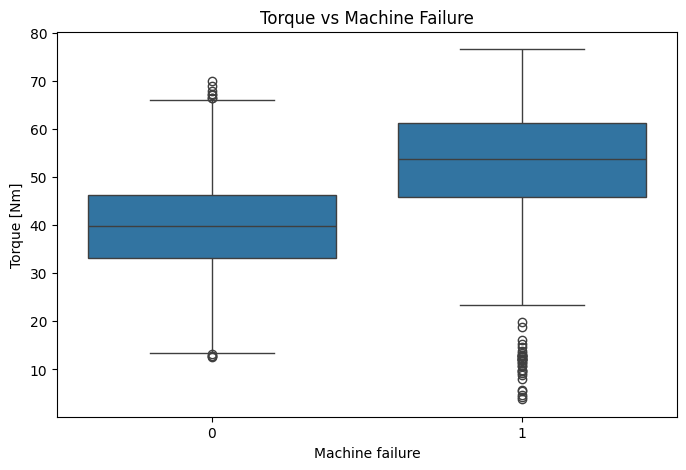

In [ ]:
# Failure vs Torque

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Machine failure"],
    y="Torque [Nm]",
    data=df
)

plt.title("Torque vs Machine Failure")

plt.show()

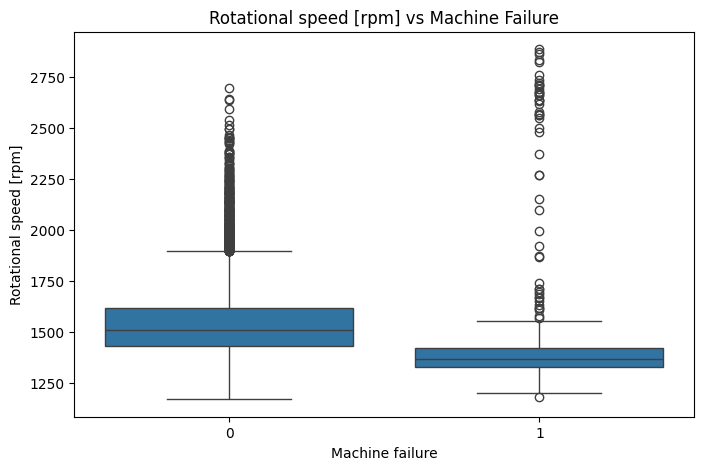

In [ ]:
# Failure vs RPM

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Machine failure",
    y="Rotational speed [rpm]",
    data=df
)

plt.title("Rotational speed [rpm] vs Machine Failure")

plt.show()

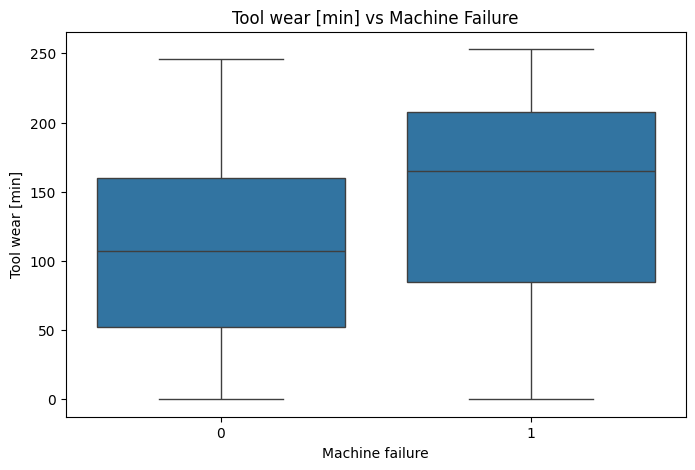

In [ ]:
# Failure vs Tool Wear
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="Tool wear [min]",
    data=df
)
plt.title("Tool wear [min] vs Machine Failure")
plt.show()

### Multivariate Analysis

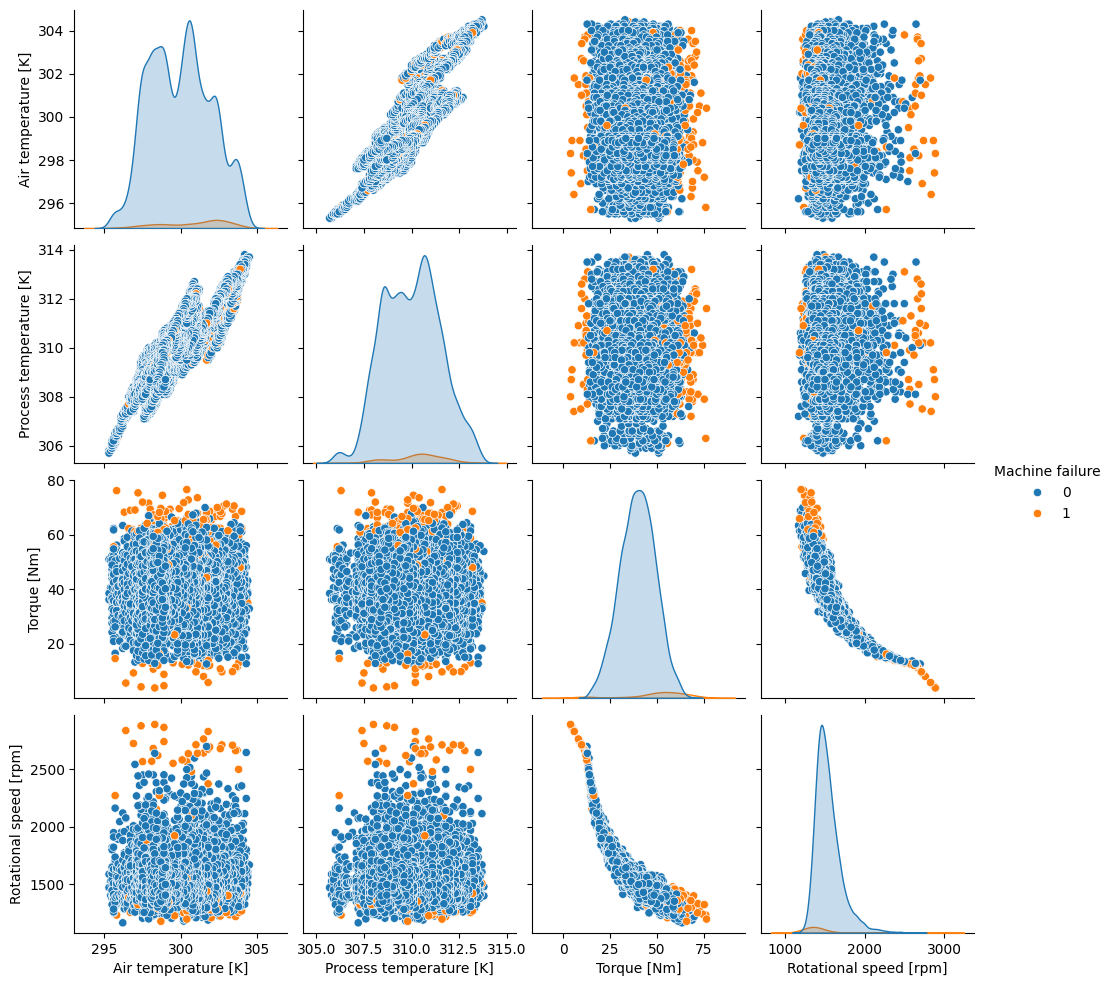

In [ ]:
sns.pairplot(
    df[
        [
            "Air temperature [K]",
            "Process temperature [K]",
            "Torque [Nm]",
            "Rotational speed [rpm]",
            "Machine failure"
        ]
    ],
    hue="Machine failure"
)

If all failures were completely mixed with normal data, prediction would be difficult.

If all failures were perfectly separated, the problem would be unrealistically easy.

### Correlation Analysis

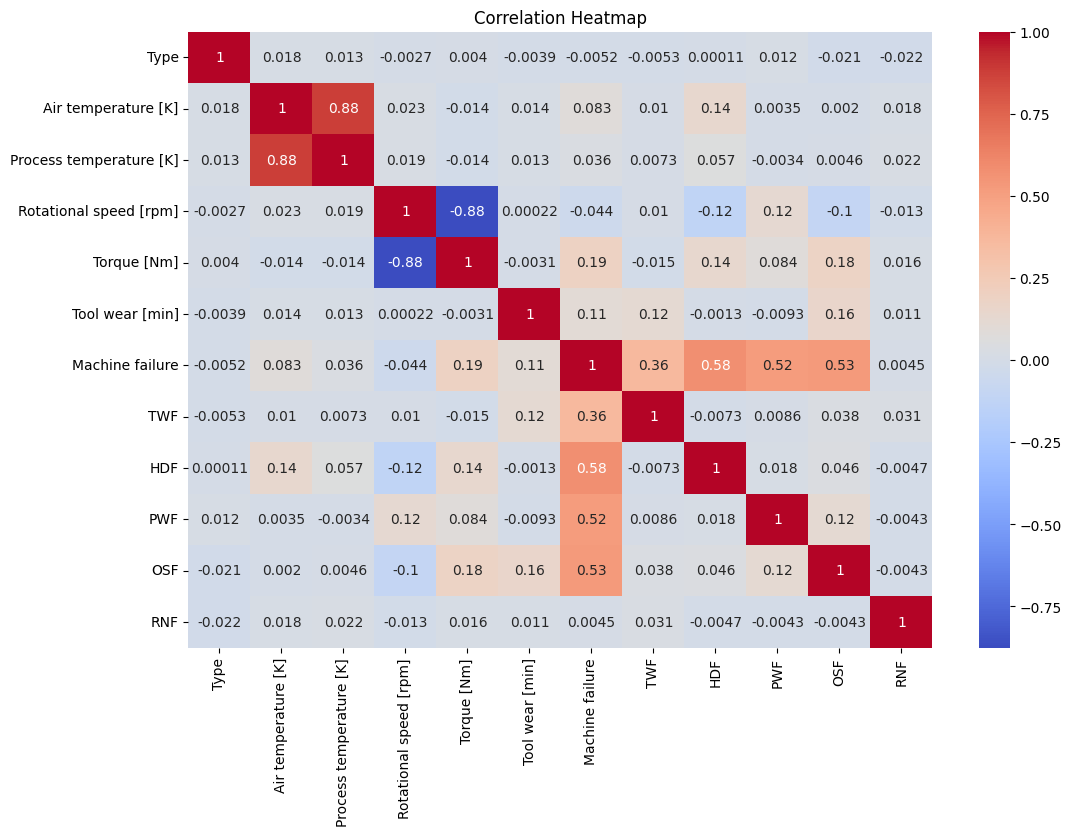

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Failure Sensor Analysis

In [ ]:
failure_analysis = df.groupby(
    "Machine failure"
).mean()

In [ ]:
failure_analysis

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,,,,,,,
0,1.199979,299.973999,309.995570,1540.260014,39.629655,106.693717,0.000000,0.000000,0.000000,0.000000,0.001863
1,1.182891,300.886431,310.290265,1496.486726,50.168142,143.781711,0.135693,0.339233,0.280236,0.289086,0.002950


In [ ]:
failure_analysis = df.groupby(
    "Machine failure"
).agg(
    {
        "Air temperature [K]":"mean",
        "Process temperature [K]":"mean",
        "Rotational speed [rpm]":"mean",
        "Torque [Nm]":"mean",
        "Tool wear [min]":"mean"
    }
)

In [ ]:
failure_analysis

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


# Advanced EDA Insights

1. Machine failures are rare events (~3.39%).

2. Tool wear appears significantly higher in failure cases.

3. Torque shows strong variation between failure and non-failure machines.

4. Process temperature may contribute to machine stress.

5. Predictive maintenance models can reduce downtime by identifying failure patterns early.

## Feature Engineering

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 12)

**FEATURE 1 :** Thermal Stress Index
ENGINEERING LOGIC

Machines generate heat.

Difference between: Process Temperature - Air Temperature

tells us:  How much hotter machine is compared to environment.

**FORMULA**

Thermal Stress Index = Process Temperature − Air Temperature

In [ ]:
df["Thermal Stress Index"] = df["Process temperature [K]"] - df["Air temperature [K]"]

In [ ]:
df[["Thermal Stress Index", "Process temperature [K]", "Air temperature [K]"]].head()

,Thermal Stress Index,Process temperature [K],Air temperature [K]
0,10.5,308.6,298.1
1,10.5,308.7,298.2
2,10.4,308.5,298.1
3,10.4,308.6,298.2
4,10.5,308.7,298.2


**FEATURE 2:** Wear Efficiency
ENGINEERING LOGIC
Tool wear alone isn't enough.

Example:
Wear = 100

It Depends on RPM.

A machine running: 2500 RPM with 100 wear is different from
1200 RPM with 100 wear.

Wear Efficiency
=
Tool Wear
Rotational Speed
+
1
Wear Efficiency=Rotational Speed+1Tool Wear​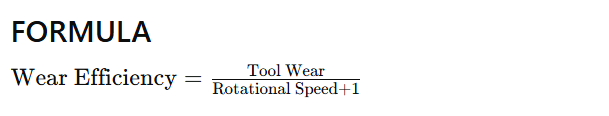

In [ ]:
df["Wear Efficiency"] = (
    df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)
)

**FEATURE 3 : ** Operational Load Index
ENGINEERING LOGIC

High RPM alone isn't enough.

High Torque alone isn't enough.

Together they represent machine load.

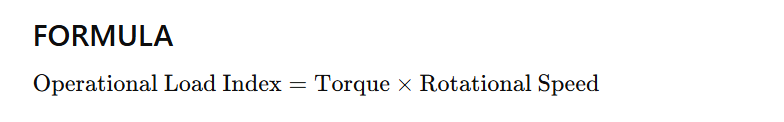

In [ ]:
df["Operational Load Index"] = (
    df["Torque [Nm]"]
    *
    df["Rotational speed [rpm]"]
)

**FEATURE 4 : ** Temperature Ratio

ENGINEERING LOGIC

Instead of difference:

use relative relationship.

In [ ]:
df["Temperature Ratio"] = (
    df["Process temperature [K]"]
    /
    df["Air temperature [K]"]
)

**FEATURE 5 : **Power Consumption Proxy

ENGINEERING LOGIC

Actual power isn't available.

But physics tells us:

Power roughly depends on:

Torque × RPM

In [ ]:
df["Power Proxy"] = (
    df["Torque [Nm]"]
    *
    df["Rotational speed [rpm]"]
)
# NOTE

# This is similar to Operational Load.

# Later we may remove one if highly correlated.

# For learning, keep both.

**FEATURE 6 :** Failure Risk Score

This is a custom AI feature.

ENGINEERING LOGIC

Failure risk often increases with:

wear, torque

In [ ]:
df["Failure Risk Score"] = (
    df["Tool wear [min]"]
    *
    df["Torque [Nm]"]
)

In [ ]:
new_features = [
    "Thermal Stress Index",
    "Wear Efficiency",
    "Operational Load Index",
    "Temperature Ratio",
    "Power Proxy",
    "Failure Risk Score"
]

df[new_features].head()

,Thermal Stress Index,Wear Efficiency,Operational Load Index,Temperature Ratio,Power Proxy,Failure Risk Score
0,10.5,0.000000,66382.8,1.035223,66382.8,0.0
1,10.5,0.002129,65190.4,1.035211,65190.4,138.9
2,10.4,0.003336,74001.2,1.034888,74001.2,247.0
3,10.4,0.004881,56603.5,1.034876,56603.5,276.5
4,10.5,0.006388,56320.0,1.035211,56320.0,360.0


In [ ]:
df[new_features].head().T

,0,1,2,3,4
Thermal Stress Index,10.500000,10.500000,10.400000,10.400000,10.500000
Wear Efficiency,0.000000,0.002129,0.003336,0.004881,0.006388
Operational Load Index,66382.800000,65190.400000,74001.200000,56603.500000,56320.000000
Temperature Ratio,1.035223,1.035211,1.034888,1.034876,1.035211
Power Proxy,66382.800000,65190.400000,74001.200000,56603.500000,56320.000000
Failure Risk Score,0.000000,138.900000,247.000000,276.500000,360.000000


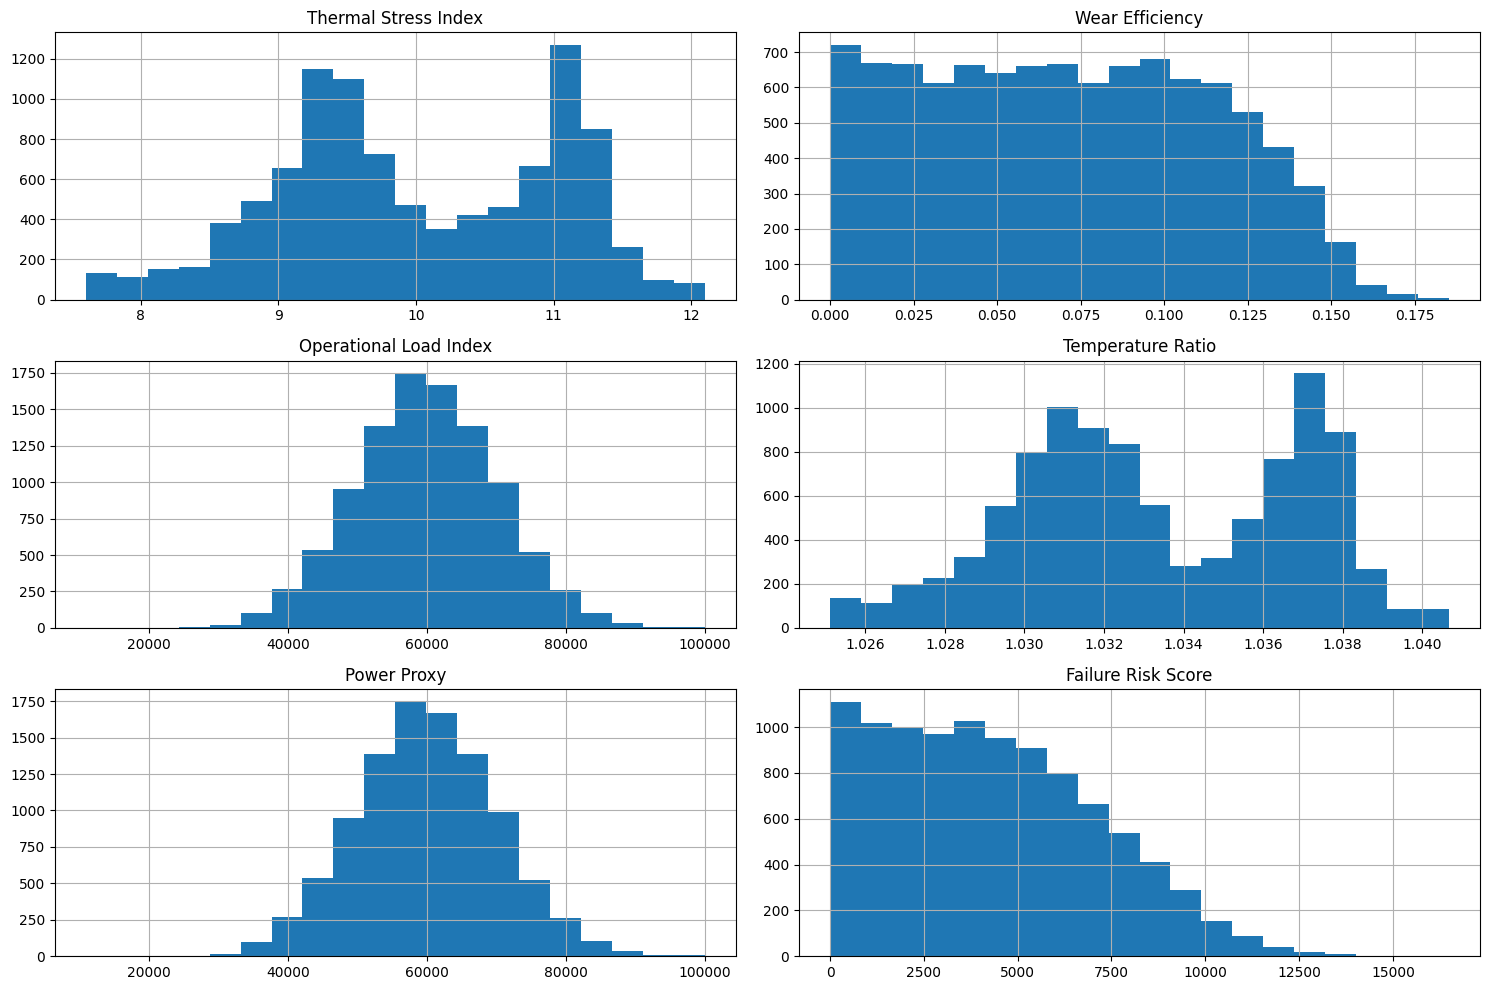

In [ ]:
df[new_features].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
# automatically adjusts subplot parameters (like padding and spacing)
# so that axis labels, tick marks, and titles fit neatly into the figure area without overlapping

plt.show()

In [ ]:
# Correlation with Failure
correlation = (
    df.corr(numeric_only=True)
    ["Machine failure"]
    .sort_values(ascending=False)
)


In [ ]:
correlation

,Machine failure
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Failure Risk Score,0.190427
Operational Load Index,0.176039
Power Proxy,0.176039
Wear Efficiency,0.130194


In [ ]:
df.to_csv(
    "featured_data.csv",
    index=False
)

In [ ]:
print(df.shape)

(10000, 18)


In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Thermal Stress Index,Wear Efficiency,Operational Load Index,Temperature Ratio,Power Proxy,Failure Risk Score
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0.000000,66382.8,1.035223,66382.8,0.0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0.002129,65190.4,1.035211,65190.4,138.9
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0.003336,74001.2,1.034888,74001.2,247.0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0.004881,56603.5,1.034876,56603.5,276.5
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0.006388,56320.0,1.035211,56320.0,360.0


In [ ]:
print(df.shape)

(10000, 18)


In [ ]:
correlation.head(10)

,Machine failure
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Failure Risk Score,0.190427
Operational Load Index,0.176039
Power Proxy,0.176039
Wear Efficiency,0.130194


In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Thermal Stress Index,Wear Efficiency,Operational Load Index,Temperature Ratio,Power Proxy,Failure Risk Score
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0.000000,66382.8,1.035223,66382.8,0.0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0.002129,65190.4,1.035211,65190.4,138.9
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0.003336,74001.2,1.034888,74001.2,247.0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0.004881,56603.5,1.034876,56603.5,276.5
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0.006388,56320.0,1.035211,56320.0,360.0


In [ ]:
df = df.drop(
    columns=[
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF",
        "Power Proxy"
    ]
)

print(df.shape)

(10000, 12)


In [ ]:
df.to_csv(
    "featured_data.csv",
    index=False
)

In [43]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


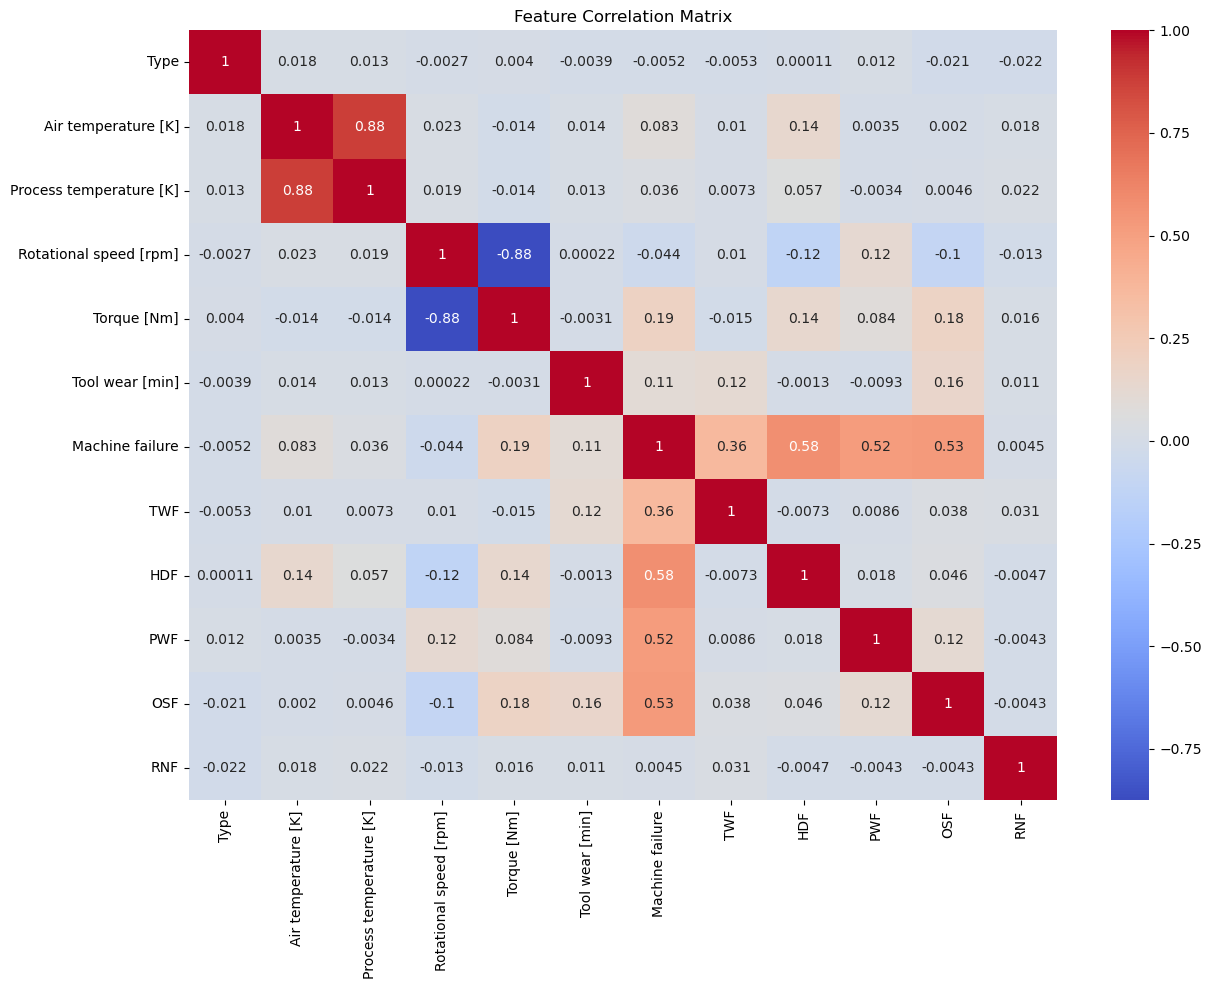

In [44]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [45]:
df.to_csv(
    "final_ml_data.csv",
    index=False
)

In [46]:
print(df.shape)

(10000, 12)


In [47]:
df.columns.tolist()

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

### MACHINE LEARNING MODEL TRAINING

In [48]:
!pip install catboost

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\INDIAN\\AppData\\Local\\Temp\\pip-unpack-2tq8jl6j\\catboost-1.2.10-cp313-cp313-win_amd64.whl'
Consider using the `--user` option or check the permissions.




   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 219.1 kB/s eta 0:07:35
   ---------------------------------------- 0.5/100.2 MB 219.1 kB/s eta 0:07:35
   ---------------------------------------- 0.5/100.2 MB 219.1 kB/s eta 0:07:35
   ---------------------------------------- 0.5/100.2 MB 219.1 kB/s eta 0:07:35
   -------------------------------------

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
df=pd.read_csv("/content/final_ml_data.csv")

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Thermal Stress Index,Wear Efficiency,Operational Load Index,Temperature Ratio,Failure Risk Score
0,2,298.1,308.6,1551,42.8,0,0,10.5,0.000000,66382.8,1.035223,0.0
1,1,298.2,308.7,1408,46.3,3,0,10.5,0.002129,65190.4,1.035211,138.9
2,1,298.1,308.5,1498,49.4,5,0,10.4,0.003336,74001.2,1.034888,247.0
3,1,298.2,308.6,1433,39.5,7,0,10.4,0.004881,56603.5,1.034876,276.5
4,1,298.2,308.7,1408,40.0,9,0,10.5,0.006388,56320.0,1.035211,360.0


In [ ]:
df.shape

(10000, 12)

In [ ]:
X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

In [ ]:
y

,Machine failure
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
# Few Models in ML, won't allow special charecters, due to that renaming the column names
df.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(">", "")
       .replace(" ", "_")
    for col in df.columns
]

In [ ]:
print(df.columns.tolist())

['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'Thermal_Stress_Index', 'Wear_Efficiency', 'Operational_Load_Index', 'Temperature_Ratio', 'Failure_Risk_Score']


In [ ]:
X = df.drop("Machine_failure", axis=1)

y = df["Machine_failure"]

In [ ]:
X

,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Thermal_Stress_Index,Wear_Efficiency,Operational_Load_Index,Temperature_Ratio,Failure_Risk_Score
0,2,298.1,308.6,1551,42.8,0,10.5,0.000000,66382.8,1.035223,0.0
1,1,298.2,308.7,1408,46.3,3,10.5,0.002129,65190.4,1.035211,138.9
2,1,298.1,308.5,1498,49.4,5,10.4,0.003336,74001.2,1.034888,247.0
3,1,298.2,308.6,1433,39.5,7,10.4,0.004881,56603.5,1.034876,276.5
4,1,298.2,308.7,1408,40.0,9,10.5,0.006388,56320.0,1.035211,360.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,9.6,0.008723,47318.0,1.032129,413.0
9996,0,298.9,308.4,1632,31.8,17,9.5,0.010410,51897.6,1.031783,540.6
9997,2,299.0,308.6,1645,33.4,22,9.6,0.013366,54943.0,1.032107,734.8
9998,0,299.0,308.7,1408,48.5,25,9.7,0.017743,68288.0,1.032441,1212.5


In [ ]:
y

,Machine_failure
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
X.shape

(10000, 11)

In [ ]:
y.shape

(10000,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
X_test.shape

(2000, 11)

In [ ]:
y_train.shape

(8000,)

In [ ]:
y_test.shape

(2000,)

In [ ]:
# FEATURE SCALING

scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(X_train)

In [ ]:
x_train_scaled

array([[ 1.34125703,  0.99891359,  0.60428162, ...,  0.85238725,
        -1.11285951, -0.62194451],
       [ 1.34125703, -1.50519408, -1.15325984, ...,  0.48036335,
         1.34617888,  0.64614014],
       [ 1.34125703,  0.49809206,  1.07746586, ...,  0.18404108,
         0.5344665 ,  0.68954438],
       ...,
       [-2.00769935,  0.14751698,  1.00986812, ...,  0.00287278,
         1.13083568, -1.10414292],
       [-0.33322116,  0.84866713,  0.80707487, ...,  0.42247387,
        -0.53428194,  0.17323251],
       [-0.33322116, -0.65379747, -0.20689136, ...,  0.8229347 ,
         0.99614519, -1.45939103]])

In [ ]:
x_test_scaled = scaler.fit_transform(X_test)

In [ ]:
x_test_scaled

array([[-0.32840726,  0.24686469, -0.13562611, ...,  2.44763164,
        -0.68520365,  1.83431562],
       [-0.32840726,  1.83585599,  1.59676337, ...,  0.08139672,
        -1.34124353,  0.36855035],
       [-0.32840726,  1.23998425,  0.93045973, ..., -0.12391193,
        -1.12041054,  1.22596482],
       ...,
       [ 1.30545971, -0.94487878, -1.40160303, ...,  0.20315778,
        -0.13612444,  0.2862422 ],
       [ 1.30545971,  1.19032827,  1.26361155, ...,  0.61239495,
        -0.55212054,  1.62687947],
       [ 1.30545971, -1.04419073, -0.66866902, ..., -1.73069787,
         1.11396183, -1.24966209]])

In [ ]:
# CREATE RESULTS DICTIONARY
results = {}
lr_model = LogisticRegression(
    class_weight = "balanced",
    random_state=42
)
lr_model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
lr_predict = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)[:,1]

In [ ]:
lr_predict

array([1, 0, 1, ..., 0, 1, 0])

In [ ]:
lr_prob

array([0.96535087, 0.32127428, 0.53288546, ..., 0.14481822, 0.62892298,
       0.00511768])

In [ ]:
# EVALUATE LOGISTIC REGRESSION

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, lr_predict),
    "Precision": precision_score(y_test, lr_predict),
    "Recall": recall_score(y_test, lr_predict),
    "F1": f1_score(y_test, lr_predict),
    "ROC_AUC": roc_auc_score(y_test, lr_prob)
}

Accuracy: Overall correctness.

Precision Of predicted failures: How many were actually failures?

Recall: Of actual failures:

F1: Balance of: Precision, Recall, ROC-AUC

In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.8545,
  'Precision': 0.17302052785923755,
  'Recall': 0.8676470588235294,
  'F1': 0.2885085574572127,
  'ROC_AUC': np.float64(0.9373858238947753)}}

In [ ]:
print(classification_report(y_test, lr_predict))

              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1932
           1       0.17      0.87      0.29        68

    accuracy                           0.85      2000
   macro avg       0.58      0.86      0.60      2000
weighted avg       0.97      0.85      0.90      2000



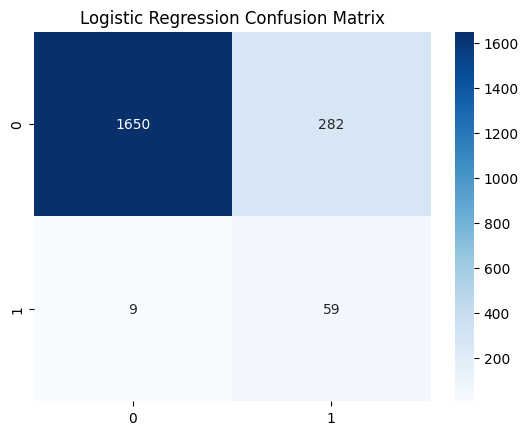

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [ ]:
# RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:
rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [ ]:
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
}

In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.92      0.81      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



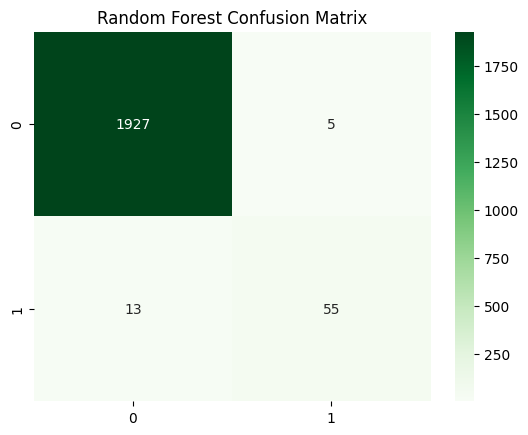

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.8545,
  'Precision': 0.17302052785923755,
  'Recall': 0.8676470588235294,
  'F1': 0.2885085574572127,
  'ROC_AUC': np.float64(0.9373858238947753)},
 'Random Forest': {'Accuracy': 0.991,
  'Precision': 0.9166666666666666,
  'Recall': 0.8088235294117647,
  'F1': 0.859375,
  'ROC_AUC': np.float64(0.9884986603336987)}}

In [ ]:
!pip install xgboost

In [ ]:
df.columns.tolist()

['Type',
 'Air_temperature_K',
 'Process_temperature_K',
 'Rotational_speed_rpm',
 'Torque_Nm',
 'Tool_wear_min',
 'Machine_failure',
 'Thermal_Stress_Index',
 'Wear_Efficiency',
 'Operational_Load_Index',
 'Temperature_Ratio',
 'Failure_Risk_Score']

In [ ]:
# XGBOOST
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#predictions
xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [ ]:
#Evaluation
results["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC_AUC": roc_auc_score(y_test, xgb_prob)
}

In [ ]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.90      0.82      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000



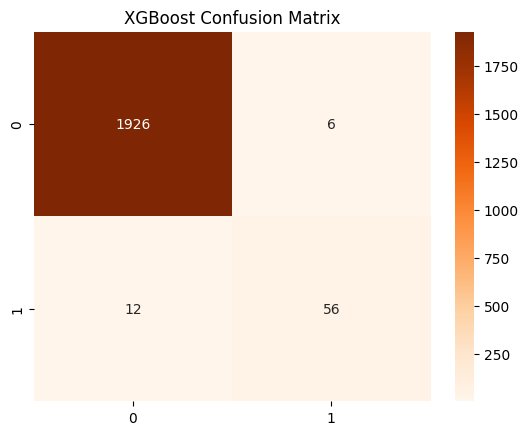

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.8545,
  'Precision': 0.17302052785923755,
  'Recall': 0.8676470588235294,
  'F1': 0.2885085574572127,
  'ROC_AUC': np.float64(0.9373858238947753)},
 'Random Forest': {'Accuracy': 0.991,
  'Precision': 0.9166666666666666,
  'Recall': 0.8088235294117647,
  'F1': 0.859375,
  'ROC_AUC': np.float64(0.9884986603336987)},
 'XGBoost': {'Accuracy': 0.991,
  'Precision': 0.9032258064516129,
  'Recall': 0.8235294117647058,
  'F1': 0.8615384615384616,
  'ROC_AUC': np.float64(0.9858041042503958)}}

In [ ]:
!pip install lightgbm

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001958 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2028
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [ ]:
lgbm_pred = lgbm_model.predict(
    X_test
)

lgbm_prob = lgbm_model.predict_proba(
    X_test
)[:,1]

In [ ]:
results["LightGBM"] = {
    "Accuracy": accuracy_score(y_test, lgbm_pred),
    "Precision": precision_score(y_test, lgbm_pred),
    "Recall": recall_score(y_test, lgbm_pred),
    "F1": f1_score(y_test, lgbm_pred),
    "ROC_AUC": roc_auc_score(y_test, lgbm_prob)
}

In [ ]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.9910,0.916667,0.808824,0.859375,0.988499
XGBoost,0.9910,0.903226,0.823529,0.861538,0.985804
LightGBM,0.9925,0.934426,0.838235,0.883721,0.979722
Logistic Regression,0.8545,0.173021,0.867647,0.288509,0.937386


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,Rotational_speed_rpm,0.208731
10,Failure_Risk_Score,0.194577
8,Operational_Load_Index,0.175978
6,Thermal_Stress_Index,0.093850
5,Tool_wear_min,0.083246
9,Temperature_Ratio,0.069238
4,Torque_Nm,0.063841
0,Type,0.039240
7,Wear_Efficiency,0.032607
1,Air_temperature_K,0.020049


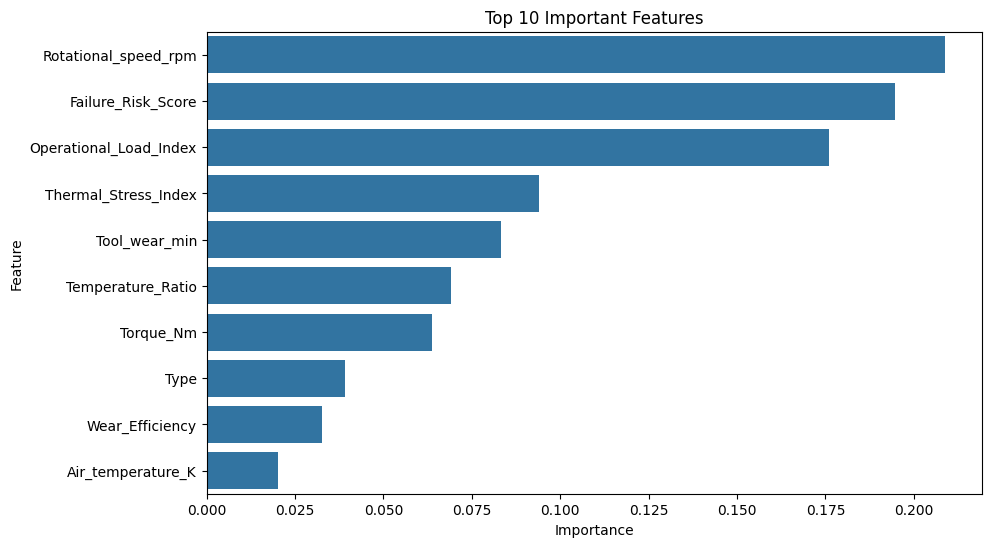

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.8545,
  'Precision': 0.17302052785923755,
  'Recall': 0.8676470588235294,
  'F1': 0.2885085574572127,
  'ROC_AUC': np.float64(0.9373858238947753)},
 'Random Forest': {'Accuracy': 0.991,
  'Precision': 0.9166666666666666,
  'Recall': 0.8088235294117647,
  'F1': 0.859375,
  'ROC_AUC': np.float64(0.9884986603336987)},
 'XGBoost': {'Accuracy': 0.991,
  'Precision': 0.9032258064516129,
  'Recall': 0.8235294117647058,
  'F1': 0.8615384615384616,
  'ROC_AUC': np.float64(0.9858041042503958)},
 'LightGBM': {'Accuracy': 0.9925,
  'Precision': 0.9344262295081968,
  'Recall': 0.8382352941176471,
  'F1': 0.8837209302325582,
  'ROC_AUC': np.float64(0.9797223237120934)}}

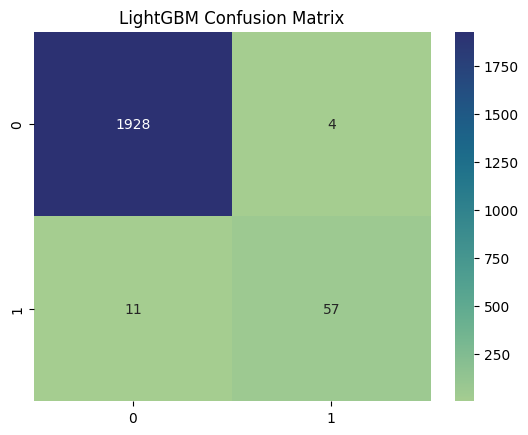

In [ ]:
cm = confusion_matrix(
    y_test,
    lgbm_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest"
)

plt.title(
    "LightGBM Confusion Matrix"
)

plt.show()

# Project Findings

A predictive maintenance system was developed using the AI4I 2020 dataset.

The project involved:

* Data Cleaning and Preprocessing
* Exploratory Data Analysis
* Feature Engineering
* Machine Learning Model Development
* Model Comparison

Several engineered features were created, including:

* Thermal Stress Index
* Wear Efficiency
* Operational Load Index
* Failure Risk Score

Among all models tested, LightGBM achieved the best overall performance:

* Accuracy: 99.25%
* Precision: 93.44%
* Recall: 83.82%
* F1 Score: 88.37%

Feature importance analysis revealed that machine rotational speed, failure risk score, and operational load index were the strongest predictors of machine failure.

These findings demonstrate how engineered operational metrics can significantly improve predictive maintenance performance in industrial and automotive environments.


## **MODEL EVALUATION**

In [ ]:
import joblib

joblib.dump(
    lgbm_model,
    "best_model.pkl"
)

['best_model.pkl']

In [ ]:
# Load Model
model = joblib.load("/content/best_model.pkl")

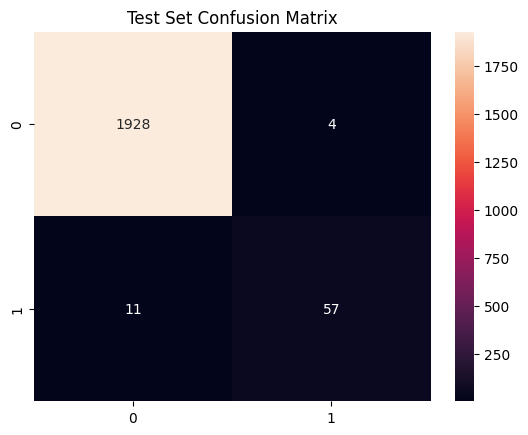

In [ ]:
predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Test Set Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.84      0.88        68

    accuracy                           0.99      2000
   macro avg       0.96      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
# Load Model
model = joblib.load(
    "/content/best_model.pkl"
)

In [ ]:
df = pd.read_csv(
    "/content/final_ml_data.csv"
)

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Thermal Stress Index,Wear Efficiency,Operational Load Index,Temperature Ratio,Failure Risk Score
0,2,298.1,308.6,1551,42.8,0,0,10.5,0.000000,66382.8,1.035223,0.0
1,1,298.2,308.7,1408,46.3,3,0,10.5,0.002129,65190.4,1.035211,138.9
2,1,298.1,308.5,1498,49.4,5,0,10.4,0.003336,74001.2,1.034888,247.0
3,1,298.2,308.6,1433,39.5,7,0,10.4,0.004881,56603.5,1.034876,276.5
4,1,298.2,308.7,1408,40.0,9,0,10.5,0.006388,56320.0,1.035211,360.0


In [ ]:
# Clean column names
df.columns = [
    col.replace("[", "")
       .replace("]", "")
       .replace("<", "")
       .replace(">", "")
       .replace(" ", "_")
    for col in df.columns
]

In [ ]:
X = df.drop(
    "Machine_failure",
    axis=1
)
y=df["Machine_failure"]

In [ ]:
X.shape

(10000, 11)

In [ ]:
y.shape

(10000,)

In [ ]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(model)

In [ ]:
#generate shap values
shap_values = explainer.shap_values(X)

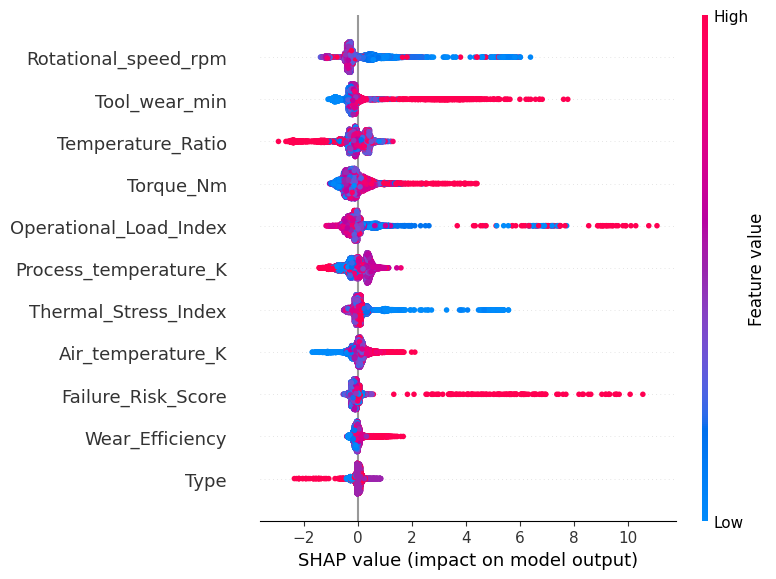

In [ ]:
shap.summary_plot(shap_values, X)

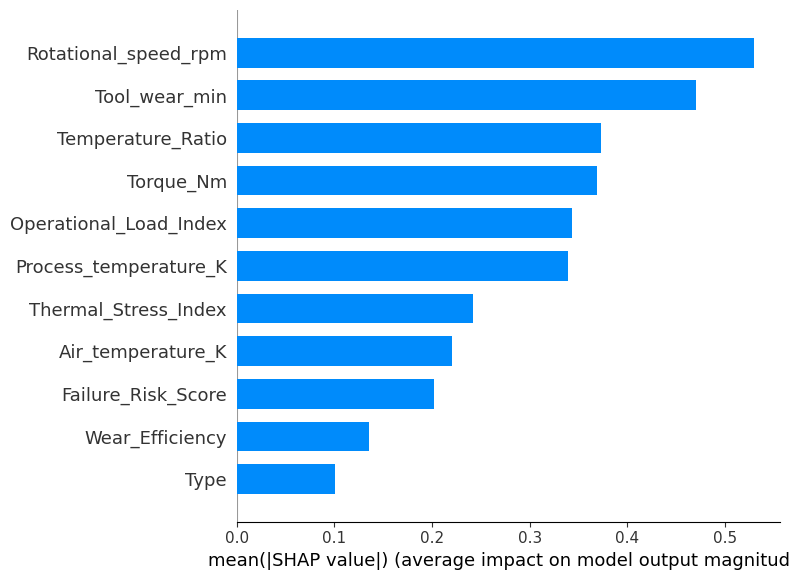

In [ ]:
shap.summary_plot(shap_values, X, plot_type="bar")

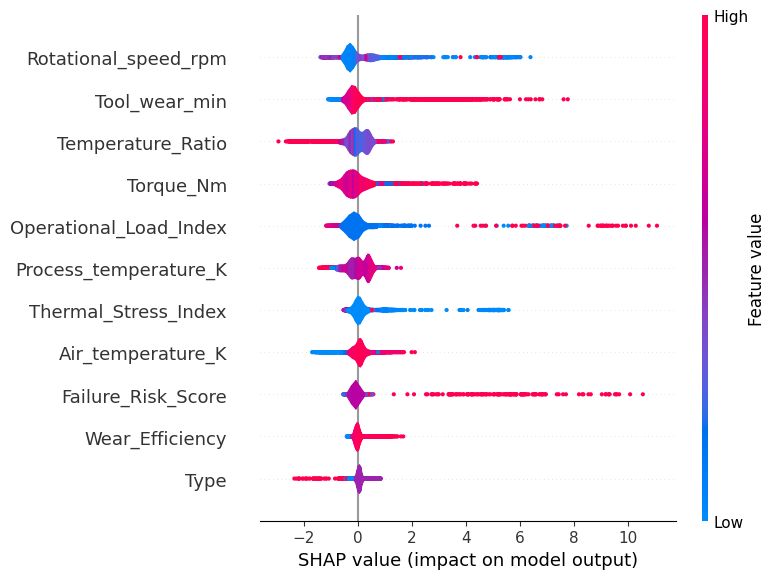

In [ ]:
shap.summary_plot(shap_values, X, plot_type="violin")

In [ ]:
sample_index = 0

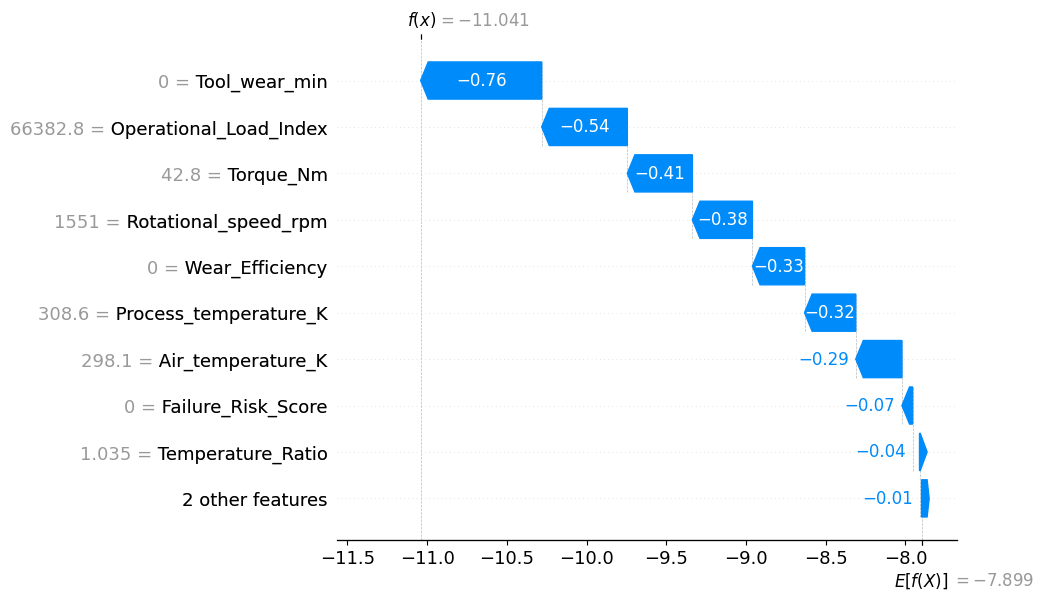

In [ ]:
# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X.iloc[sample_index],
        feature_names=X.columns
    )
)

In [ ]:
failure_index = y[y==1].index[0]

failure_index

np.int64(50)

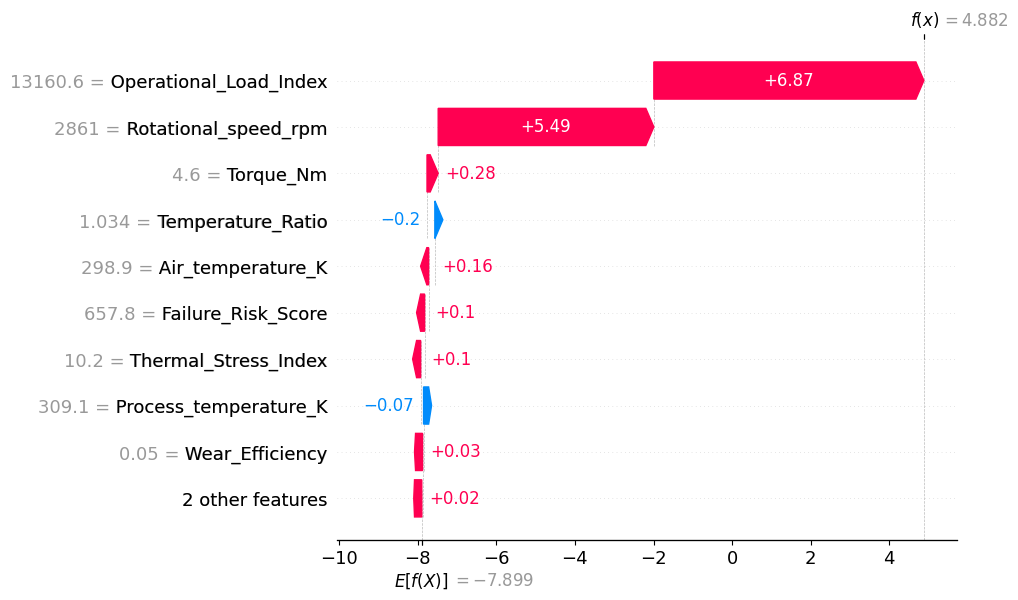

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[failure_index],
        base_values=explainer.expected_value,
        data=X.iloc[failure_index],
        feature_names=X.columns
    )
)

# Waterfall Plot Interpretation

The analyzed machine was predicted as a failure case.

The primary factors increasing failure probability were:

1. Operational Load Index
2. Rotational Speed
3. Torque

Among these, Operational Load Index had the strongest impact, indicating that the machine was operating under excessive mechanical load.

The SHAP analysis confirms that machine speed and load are the most influential predictors of failure, aligning with the feature importance results obtained from XGBoost and LightGBM models.

This demonstrates that the model predictions are explainable and consistent with engineering intuition.

# Explainable AI Findings

The SHAP analysis revealed:

1. Rotational Speed was the most influential feature.

2. Failure Risk Score significantly increased failure probability.

3. Operational Load Index contributed strongly to machine failure.

4. Thermal Stress Index had measurable impact on failure prediction.

5. Feature Engineering created highly informative predictors.

These findings align with domain knowledge in predictive maintenance and industrial machinery health monitoring.

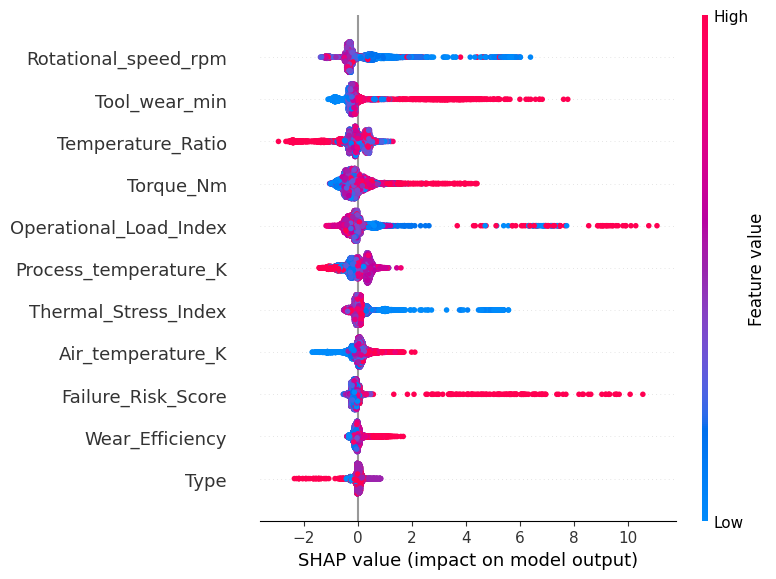

In [ ]:
shap.summary_plot(
    shap_values,
    X
)

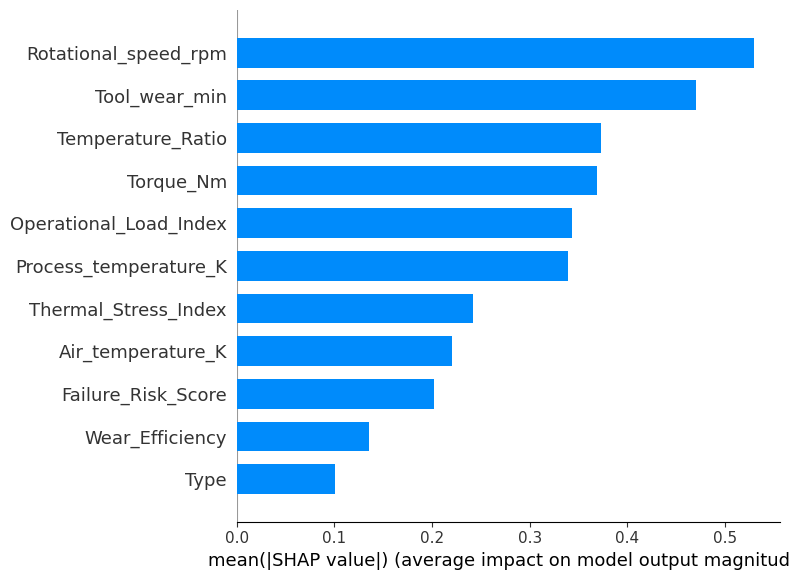

In [ ]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [50]:
shap.dependence_plot(
    "Rotational_speed_rpm",
    shap_values,
    X
)

NameError: name 'shap' is not defined